**Import Libraries**

In [94]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database connection
from sqlalchemy import create_engine

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

**Load Dataset**

In [95]:
# Load customer dataset
df = pd.read_csv("Customer_Data.csv")

# View first 5 rows
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


**Initial Data Understanding**

In [96]:
# Check dataset shape
print(df.shape)



(6418, 32)


In [97]:
# Check column names
print(df.columns)

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'State',
       'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')


In [98]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [99]:
# Summary statistics
df.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [100]:
# Missing values
df.isnull().sum()

Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3548
Phone_Service                     0
Multiple_Lines                  622
Internet_Service                  0
Internet_Type                  1390
Online_Security                1390
Online_Backup                  1390
Device_Protection_Plan         1390
Premium_Support                1390
Streaming_TV                   1390
Streaming_Movies               1390
Streaming_Music                1390
Unlimited_Data                 1390
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

****Data Cleaning**

**1 Remove Duplicates**

In [101]:
# Remove duplicate records
df = df.drop_duplicates()

** Correct Data Types**

In [102]:
# Convert Total Charges to numeric
# Convert columns to numeric
df['Monthly_Charge'] = pd.to_numeric(df['Monthly_Charge'], errors='coerce')

df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

df['Total_Revenue'] = pd.to_numeric(df['Total_Revenue'], errors='coerce')

**Handle Missing Values**

In [103]:
# Fill missing numeric values with median

numeric_cols = [
    'Monthly_Charge',
    'Total_Charges',
    'Total_Revenue',
    'Age',
    'Tenure_in_Months'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Numeric missing values handled!")

Numeric missing values handled!


In [104]:
# Select categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Fill missing categorical values
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

print("Categorical missing values handled!")

Categorical missing values handled!


In [105]:
# Recheck missing values
df.isnull().sum()

Customer_ID                    0
Gender                         0
Age                            0
Married                        0
State                          0
Number_of_Referrals            0
Tenure_in_Months               0
Value_Deal                     0
Phone_Service                  0
Multiple_Lines                 0
Internet_Service               0
Internet_Type                  0
Online_Security                0
Online_Backup                  0
Device_Protection_Plan         0
Premium_Support                0
Streaming_TV                   0
Streaming_Movies               0
Streaming_Music                0
Unlimited_Data                 0
Contract                       0
Paperless_Billing              0
Payment_Method                 0
Monthly_Charge                 0
Total_Charges                  0
Total_Refunds                  0
Total_Extra_Data_Charges       0
Total_Long_Distance_Charges    0
Total_Revenue                  0
Customer_Status                0
Churn_Cate

**5 — Feature Engineering**

**5.1 Create Churn Flag**

In [106]:
# Convert customer status into binary churn flag
df['Churn_Flag'] = np.where(df['Customer_Status'] == 'Churned', 1, 0)

In [107]:
# Categorize customers by tenure
df['Tenure_Group'] = pd.cut(
    df['Tenure_in_Months'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
)

In [108]:
# Create customer age categories
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 80],
    labels=['18-30', '31-45', '46-60', '60+']
)

In [109]:
# Remove extra spaces from text columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

In [110]:
# Example: unique customer status values
print(df['Customer_Status'].unique())

['Stayed' 'Churned' 'Joined']


In [111]:
# Standardize status names
df['Customer_Status'] = df['Customer_Status'].replace({
    'Stayed': 'Stayed',
    'Churned': 'Churned',
    'Joined': 'Joined'
})

In [112]:
!pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [113]:
import pandas as pd
from sqlalchemy import create_engine

# PostgreSQL credentials
username = "postgres"
password = "12345"
host = "localhost"
port = "5432"
database = "customer_churn_db"

# Create PostgreSQL connection
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print("PostgreSQL connection successful!")

# Upload dataframe into PostgreSQL
df.to_sql(
    name='customer_data',
    con=engine,
    if_exists='replace',
    index=False
)

print("Data uploaded successfully!")

PostgreSQL connection successful!
Data uploaded successfully!


**CHUNK 9 — Exploratory Data Analysis (EDA)**

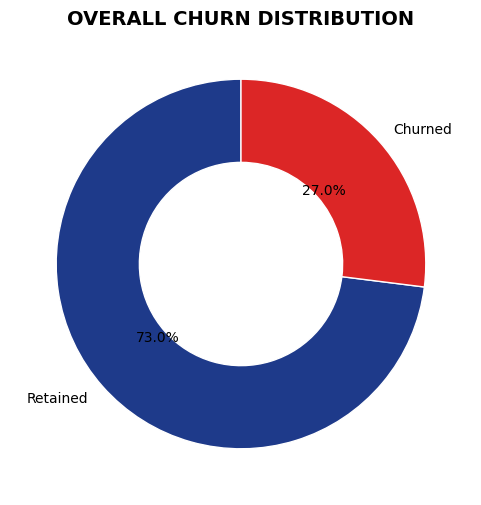

In [114]:
#Overall Churn Distribution (Donut Chart)
import matplotlib.pyplot as plt

BLUE = "#1E3A8A"
RED = "#DC2626"

sizes = df["Churn_Flag"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=["Retained", "Churned"],
    colors=[BLUE, RED],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="white")
)

plt.title(
    "OVERALL CHURN DISTRIBUTION",
    fontsize=14,
    fontweight="bold"
)

plt.show()

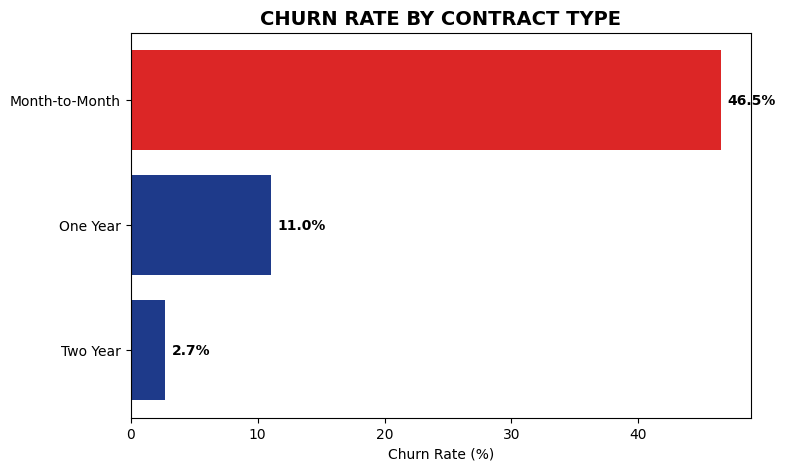

In [115]:
#Churn Rate by Contract Type
contract_churn = (
    df.groupby("Contract")["Churn_Flag"]
    .mean()
    * 100
).sort_values()

plt.figure(figsize=(8,5))

bars = plt.barh(
    contract_churn.index,
    contract_churn.values,
    color=[RED if v > 30 else BLUE for v in contract_churn.values]
)

for bar in bars:
    
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va='center',
        fontweight='bold'
    )

plt.xlabel("Churn Rate (%)")

plt.title(
    "CHURN RATE BY CONTRACT TYPE",
    fontsize=14,
    fontweight="bold"
)

plt.show()

C:\Users\dassu\AppData\Local\Temp\ipykernel_14592\3994010223.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Churn_Flag"]


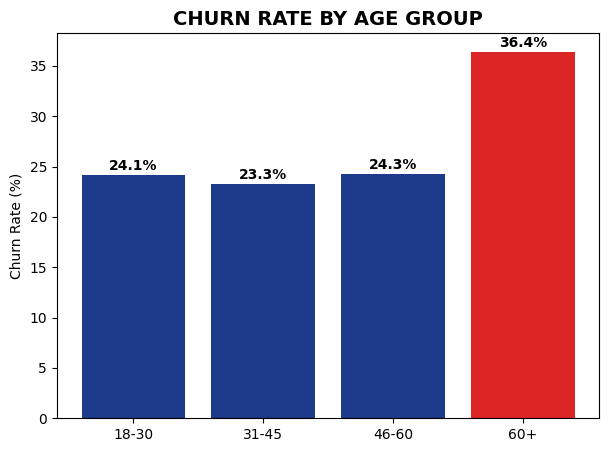

In [116]:
#Churn Rate by Age Group
age_churn = (
    df.groupby("Age_Group")["Churn_Flag"]
    .mean()
    * 100
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    age_churn.index.astype(str),
    age_churn.values,
    color=[RED if v > 30 else BLUE for v in age_churn.values]
)

for bar in bars:
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha='center',
        fontweight='bold'
    )

plt.ylabel("Churn Rate (%)")

plt.title(
    "CHURN RATE BY AGE GROUP",
    fontsize=14,
    fontweight="bold"
)

plt.show()

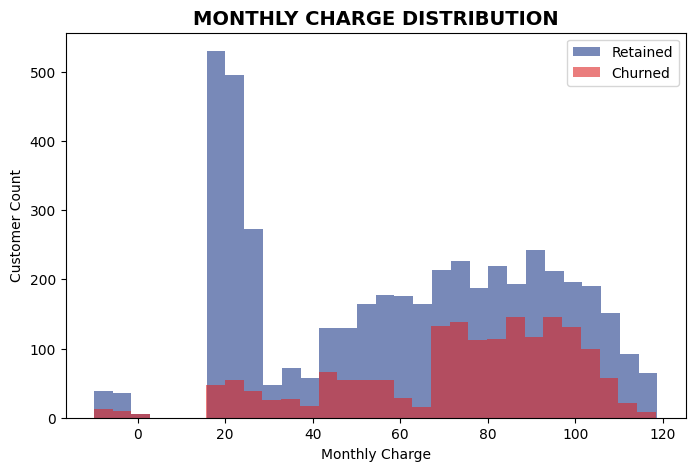

In [117]:
#Monthly Charge Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df[df["Churn_Flag"] == 0]["Monthly_Charge"],
    bins=30,
    alpha=0.6,
    label="Retained",
    color=BLUE
)

plt.hist(
    df[df["Churn_Flag"] == 1]["Monthly_Charge"],
    bins=30,
    alpha=0.6,
    label="Churned",
    color=RED
)

plt.xlabel("Monthly Charge")

plt.ylabel("Customer Count")

plt.title(
    "MONTHLY CHARGE DISTRIBUTION",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.show()

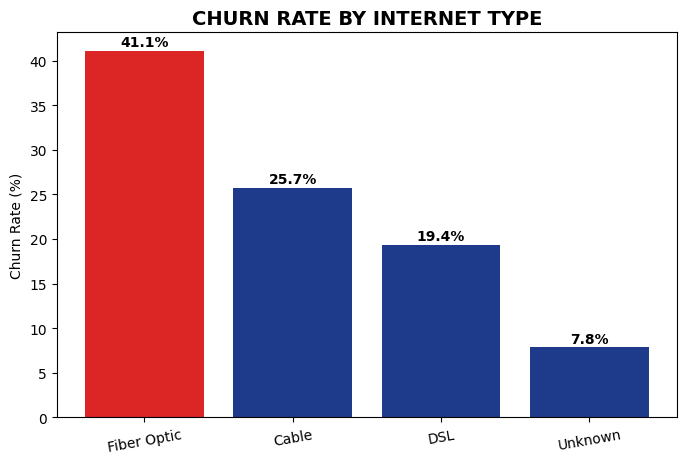

In [118]:
#Churn Rate by Internet Type
internet_churn = (
    df.groupby("Internet_Type")["Churn_Flag"]
    .mean()
    * 100
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

bars = plt.bar(
    internet_churn.index.astype(str),
    internet_churn.values,
    color=[RED if v > 30 else BLUE for v in internet_churn.values]
)

for i, v in enumerate(internet_churn.values):
    
    plt.text(
        i,
        v + 0.5,
        f"{v:.1f}%",
        ha='center',
        fontweight='bold'
    )

plt.ylabel("Churn Rate (%)")

plt.title(
    "CHURN RATE BY INTERNET TYPE",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=10)

plt.show()

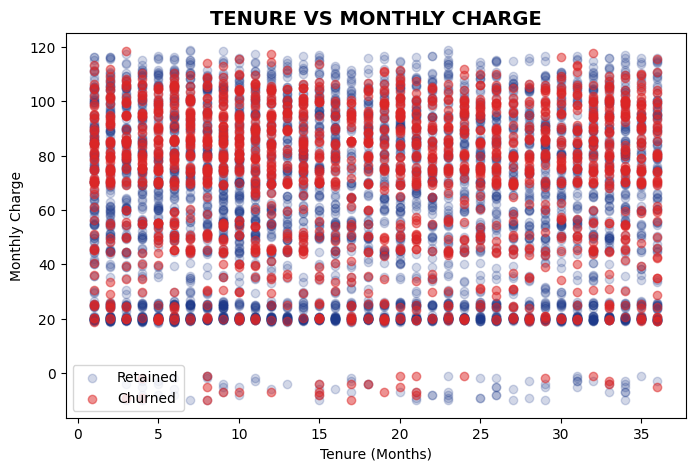

In [119]:
#Tenure vs Monthly Charge (Scatter Plot)
plt.figure(figsize=(8,5))

plt.scatter(
    df[df["Churn_Flag"] == 0]["Tenure_in_Months"],
    df[df["Churn_Flag"] == 0]["Monthly_Charge"],
    alpha=0.2,
    color=BLUE,
    label="Retained"
)

plt.scatter(
    df[df["Churn_Flag"] == 1]["Tenure_in_Months"],
    df[df["Churn_Flag"] == 1]["Monthly_Charge"],
    alpha=0.5,
    color=RED,
    label="Churned"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charge")

plt.title(
    "TENURE VS MONTHLY CHARGE",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.show()

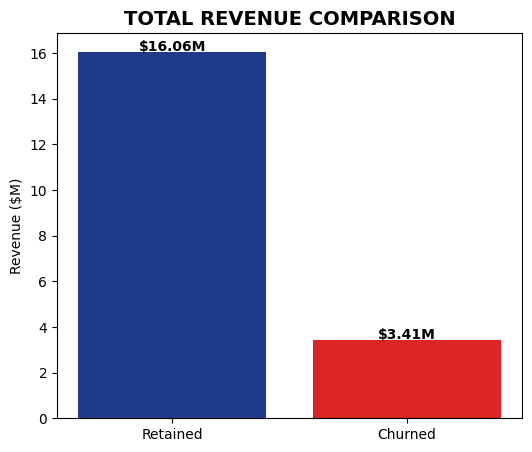

In [120]:
#Revenue Comparison (Retained vs Churned)
revenue = {
    "Retained":
        df[df["Churn_Flag"] == 0]["Total_Revenue"].sum() / 1e6,

    "Churned":
        df[df["Churn_Flag"] == 1]["Total_Revenue"].sum() / 1e6
}

plt.figure(figsize=(6,5))

bars = plt.bar(
    revenue.keys(),
    revenue.values(),
    color=[BLUE, RED]
)

for bar in bars:
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"${bar.get_height():.2f}M",
        ha='center',
        fontweight='bold'
    )

plt.ylabel("Revenue ($M)")

plt.title(
    "TOTAL REVENUE COMPARISON",
    fontsize=14,
    fontweight="bold"
)

plt.show()

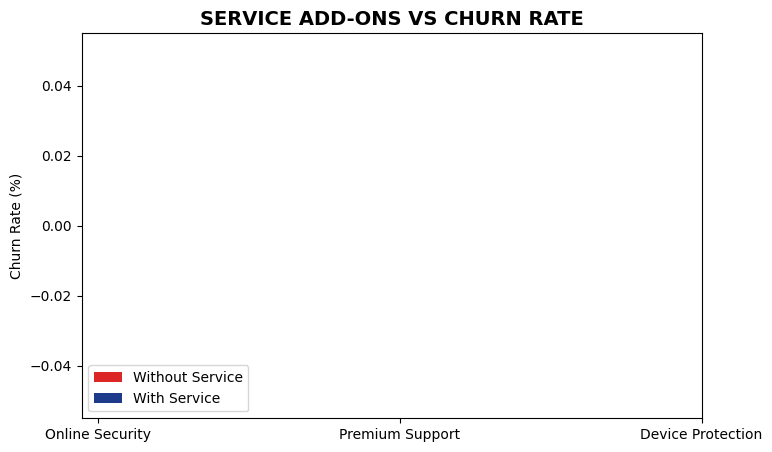

In [121]:

#Service Add-on Impact on Churn
services = [
    "Online_Security",
    "Premium_Support",
    "Device_Protection_Plan"
]

labels = [
    "Online Security",
    "Premium Support",
    "Device Protection"
]

churn_with = [
    df[df[s] == 1]["Churn_Flag"].mean() * 100
    for s in services
]

churn_without = [
    df[df[s] == 0]["Churn_Flag"].mean() * 100
    for s in services
]

x = np.arange(len(labels))

w = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - w/2,
    churn_without,
    width=w,
    label="Without Service",
    color=RED
)

plt.bar(
    x + w/2,
    churn_with,
    width=w,
    label="With Service",
    color=BLUE
)

plt.xticks(x, labels)

plt.ylabel("Churn Rate (%)")

plt.title(
    "SERVICE ADD-ONS VS CHURN RATE",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.show()

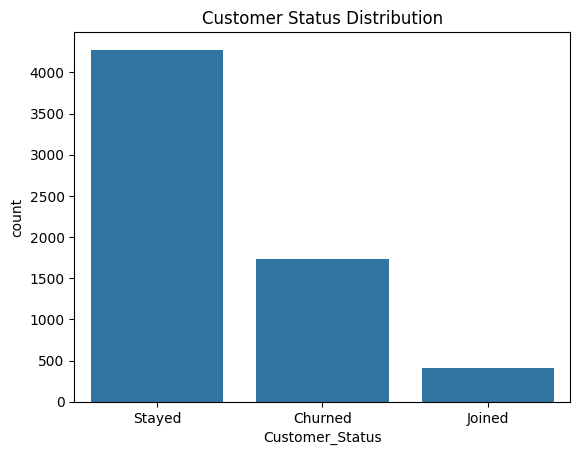

In [122]:
# Plot customer status distribution
sns.countplot(x='Customer_Status', data=df)

plt.title("Customer Status Distribution")
plt.show()

**CHUNK 10 — KPI Calculation**

In [123]:
total_customers = df['Customer_ID'].nunique()

print(total_customers)

6418


In [124]:
total_churn = df[df['Customer_Status'] == 'Churned'].shape[0]

print(total_churn)

1732


In [125]:
churn_rate = (total_churn / total_customers) * 100

print(round(churn_rate, 2))

26.99


In [126]:
# Customers with tenure <= 3 months
new_joiners = df[df['Tenure_in_Months'] <= 3].shape[0]

print(new_joiners)

644


**CHUNK 11 — Churner Profile Analysis**

In [127]:
# Average values for churned customers
df[df['Customer_Status'] == 'Churned'].describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Churn_Flag
count,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.0
mean,50.144919,7.392610,17.515589,73.102252,1534.118245,1.461911,7.338337,429.959475,1969.954145,1.0
std,17.693922,4.548921,10.662421,26.505566,1903.533619,6.891654,25.270686,647.073852,2444.980701,0.0
min,18.000000,0.000000,1.000000,-10.000000,19.100000,0.000000,0.000000,0.000000,21.610000,1.0
25%,35.000000,3.000000,8.000000,55.150000,136.950000,0.000000,0.000000,30.960000,177.707500,1.0
50%,50.000000,7.000000,17.000000,79.400000,684.350000,0.000000,0.000000,136.835000,890.120000,1.0
75%,65.000000,11.000000,27.000000,94.125000,2317.775000,0.000000,0.000000,516.980000,2876.677500,1.0
max,84.000000,15.000000,36.000000,118.350000,8684.800000,49.570000,150.000000,3508.820000,11195.440000,1.0


In [128]:
# Churn percentage by contract type
contract_churn = pd.crosstab(
    df['Contract'],
    df['Customer_Status'],
    normalize='index'
) * 100

print(contract_churn)

Customer_Status    Churned     Joined     Stayed
Contract                                        
Month-to-Month   46.530736  11.168594  42.300670
One Year         11.040340   1.698514  87.261146
Two Year          2.734148   1.163467  96.102385


**CHUNK 12 — Data Preparation for Machine Learning**

In [129]:
# Create ML copy
ml_df = df.copy()
print(ml_df.dtypes)

Customer_ID                      object
Gender                           object
Age                               int64
Married                          object
State                            object
Number_of_Referrals               int64
Tenure_in_Months                  int64
Value_Deal                       object
Phone_Service                    object
Multiple_Lines                   object
Internet_Service                 object
Internet_Type                    object
Online_Security                  object
Online_Backup                    object
Device_Protection_Plan           object
Premium_Support                  object
Streaming_TV                     object
Streaming_Movies                 object
Streaming_Music                  object
Unlimited_Data                   object
Contract                         object
Paperless_Billing                object
Payment_Method                   object
Monthly_Charge                  float64
Total_Charges                   float64


In [130]:
# Create churn flag correctly

ml_df['Churn_Flag'] = np.where(
    df['Customer_Status'].astype(str).str.strip() == 'Churned',
    1,
    0
)

In [131]:
print(ml_df['Churn_Flag'].value_counts())

Churn_Flag
0    4686
1    1732
Name: count, dtype: int64


In [132]:
# Convert category columns to string

category_cols = ml_df.select_dtypes(
    include=['category']
).columns

for col in category_cols:
    ml_df[col] = ml_df[col].astype(str)

In [133]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical columns
for col in ml_df.select_dtypes(include='object').columns:
    
    ml_df[col] = le.fit_transform(
        ml_df[col].astype(str)
    )

print("Encoding completed successfully!")

Encoding completed successfully!


CUSTOMER CHURN ANALYSIS — RANDOM FOREST CHURN PREDICTION


Training Samples : 5134
Testing Samples  : 1284

Random Forest model trained successfully!

MODEL PERFORMANCE
Test ROC-AUC Score : 0.8577
5-Fold CV ROC-AUC  : 0.8649

Classification Report:

              precision    recall  f1-score   support

    Retained       0.90      0.81      0.85       937
     Churned       0.59      0.75      0.66       347

    accuracy                           0.79      1284
   macro avg       0.74      0.78      0.76      1284
weighted avg       0.81      0.79      0.80      1284

Generating model performance charts...


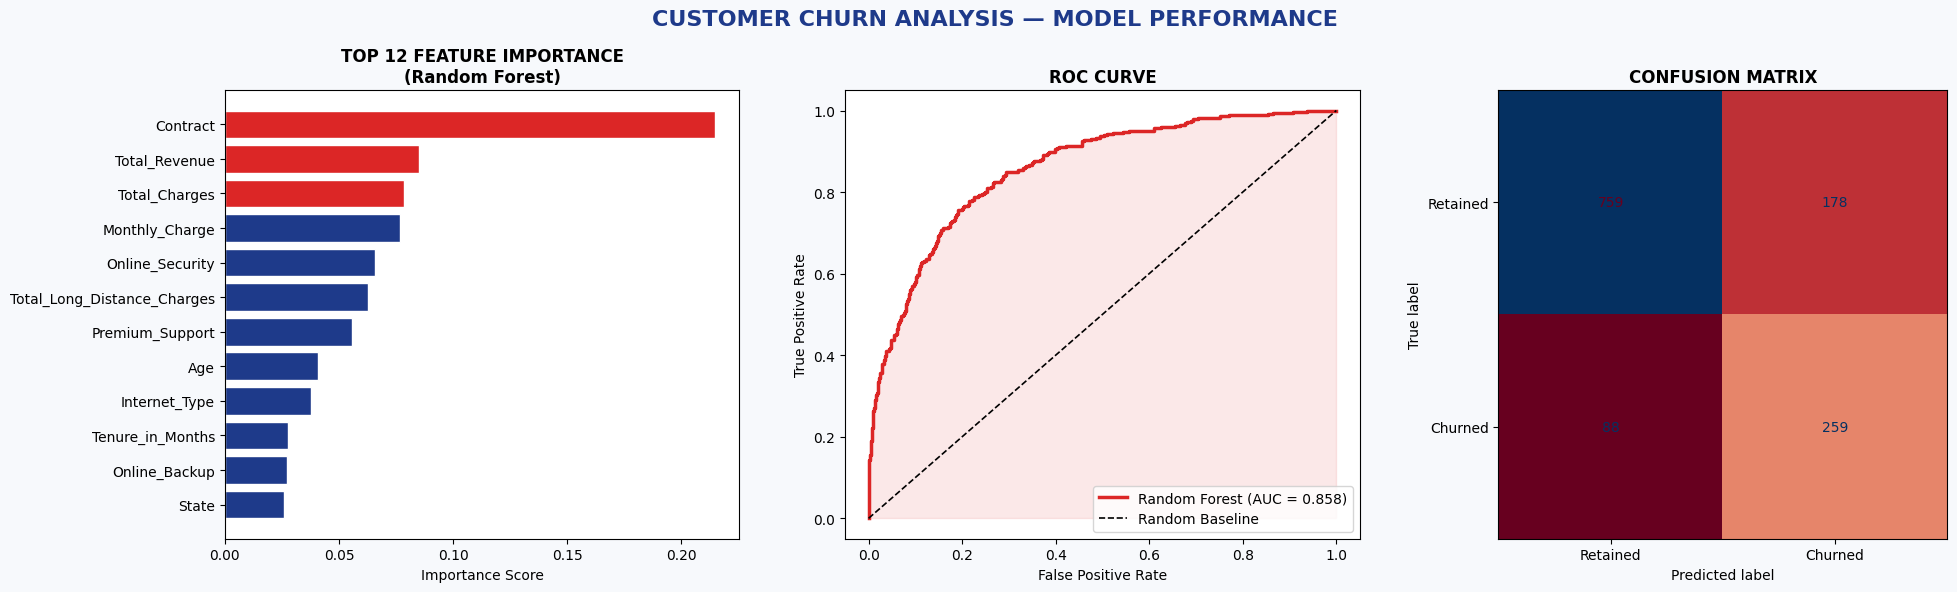


customer_churn_model_performance.png saved successfully!


In [134]:
# =============================================================================
# CUSTOMER CHURN ANALYSIS — RANDOM FOREST CHURN PREDICTION
# =============================================================================

# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)


# CUSTOM COLORS
# =============================================================================

BLUE = "#1E3A8A"
RED = "#DC2626"
BG = "#F7F9FC"



# DROP UNNECESSARY COLUMNS
# =============================================================================

DROP_COLS = [
    'Customer_ID',
    'Customer_Status',
    'Churn_Category',
    'Churn_Reason',
    'Churn_Flag'
]

# Keep only existing columns
DROP_COLS = [
    col for col in DROP_COLS
    if col in ml_df.columns
]


# FEATURE SELECTION
# =============================================================================

FEATURE_COLS = [
    col for col in ml_df.columns
    if col not in DROP_COLS
]

X = ml_df[FEATURE_COLS]

y = ml_df['Churn_Flag']

# =============================================================================
# TRAIN TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nTraining Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")


# RANDOM FOREST MODEL
# =============================================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(X_train, y_train)

print("\nRandom Forest model trained successfully!")

# =============================================================================
# PREDICTIONS
# =============================================================================

y_pred = rf.predict(X_test)

# Probability predictions
y_prob = rf.predict_proba(X_test)[:, 1]

# =============================================================================
# MODEL EVALUATION
# =============================================================================

auc = roc_auc_score(y_test, y_prob)

cv_auc = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
).mean()

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Test ROC-AUC Score : {auc:.4f}")
print(f"5-Fold CV ROC-AUC  : {cv_auc:.4f}")

# =============================================================================
# CLASSIFICATION REPORT
# =============================================================================

print("\nClassification Report:\n")

report = classification_report(
    y_test,
    y_pred,
    target_names=['Retained', 'Churned']
)

print(report)

# =============================================================================
# FEATURE IMPORTANCE & MODEL CHARTS
# =============================================================================

print("Generating model performance charts...")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle(
    "CUSTOMER CHURN ANALYSIS — MODEL PERFORMANCE",
    fontsize=16,
    fontweight='bold',
    color=BLUE
)

fig.patch.set_facecolor(BG)

# =============================================================================
# CHART 1 — FEATURE IMPORTANCE
# =============================================================================

ax = axes[0]

feat_imp = pd.Series(
    rf.feature_importances_,
    index=FEATURE_COLS
)

feat_imp = feat_imp.sort_values(
    ascending=True
).tail(12)

colors_fi = [
    RED if val >= feat_imp.values[-3]
    else BLUE
    for val in feat_imp.values
]

ax.barh(
    feat_imp.index,
    feat_imp.values,
    color=colors_fi,
    edgecolor='white'
)

ax.set_title(
    "TOP 12 FEATURE IMPORTANCE\n(Random Forest)",
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel("Importance Score")

# =============================================================================
# CHART 2 — ROC CURVE
# =============================================================================

ax = axes[1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

ax.plot(
    fpr,
    tpr,
    color=RED,
    linewidth=2.5,
    label=f"Random Forest (AUC = {auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='black',
    linewidth=1.2,
    label='Random Baseline'
)

ax.fill_between(
    fpr,
    tpr,
    alpha=0.1,
    color=RED
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_title(
    "ROC CURVE",
    fontsize=12,
    fontweight='bold'
)

ax.legend(loc='lower right')

# =============================================================================
# CHART 3 — CONFUSION MATRIX
# =============================================================================

ax = axes[2]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned']
)

disp.plot(
    ax=ax,
    cmap='RdBu',
    colorbar=False
)

ax.set_title(
    "CONFUSION MATRIX",
    fontsize=12,
    fontweight='bold'
)

# =============================================================================
# FINAL LAYOUT
# =============================================================================

plt.tight_layout()

plt.savefig(
    "customer_churn_model_performance.png",
    bbox_inches='tight',
    dpi=300,
    facecolor=BG
)

plt.show()

print("\ncustomer_churn_model_performance.png saved successfully!")

# CUSTOMER CHURN ANALYSIS — CUSTOMER RISK SEGMENTATION


 CUSTOMER RISK SEGMENTATION (RETAINED CUSTOMERS)

Total Retained Customers : 4686

RISK TIER SUMMARY
----------------------------------------------------------------------
             Customers  Avg_Churn_Probability  Avg_Monthly_Charge  \
Risk_Tier                                                           
High Risk          296                   0.73               73.25   
Medium Risk        624                   0.52               66.94   
Low Risk          3766                   0.15               58.01   

             Total_At_Risk_Revenue  
Risk_Tier                           
High Risk                296969.99  
Medium Risk             1260777.81  
Low Risk               14501682.03  


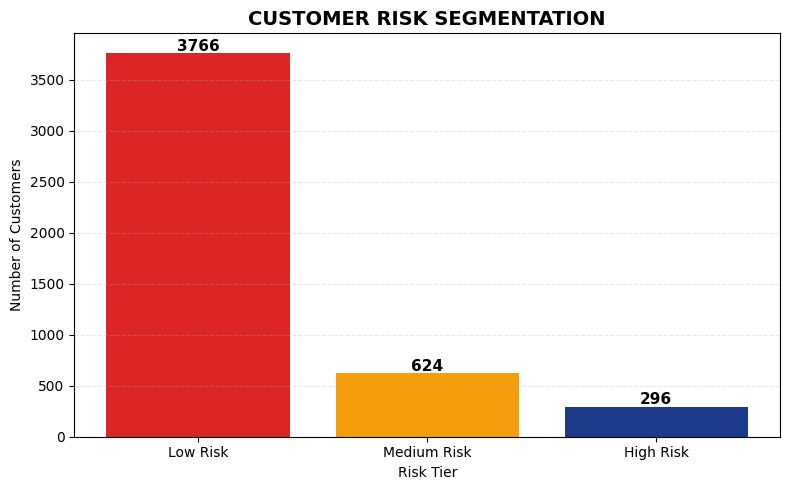


customer_risk_segmentation.png saved successfully!

customer_risk_segments.csv saved successfully!


In [137]:
# =============================================================================
# CUSTOMER CHURN ANALYSIS — CUSTOMER RISK SEGMENTATION
# =============================================================================

print("\n" + "=" * 70)
print(" CUSTOMER RISK SEGMENTATION (RETAINED CUSTOMERS)")
print("=" * 70)

# =============================================================================
# FILTER RETAINED CUSTOMERS
# =============================================================================

# Keep only retained customers
retained = df[df["Churn_Flag"] == 0].copy()

print(f"\nTotal Retained Customers : {retained.shape[0]}")

# =============================================================================
# CREATE ML DATA FOR RETAINED CUSTOMERS
# =============================================================================

# Create encoded dataframe copy
retained_ml = retained.copy()

# -----------------------------------------------------------------------------
# CONVERT CATEGORY COLUMNS TO STRING
# -----------------------------------------------------------------------------

category_cols = retained_ml.select_dtypes(
    include=['category']
).columns

for col in category_cols:
    retained_ml[col] = retained_ml[col].astype(str)

# -----------------------------------------------------------------------------
# ENCODE OBJECT COLUMNS
# -----------------------------------------------------------------------------

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

object_cols = retained_ml.select_dtypes(
    include='object'
).columns

for col in object_cols:
    retained_ml[col] = le.fit_transform(
        retained_ml[col].astype(str)
    )

# =============================================================================
# KEEP ONLY FEATURE COLUMNS
# =============================================================================

retained_X = retained_ml[FEATURE_COLS]

# =============================================================================
# PREDICT CHURN PROBABILITY
# =============================================================================

retained["Churn_Probability"] = rf.predict_proba(
    retained_X
)[:, 1]

# =============================================================================
# CREATE RISK TIERS
# =============================================================================

def risk_tier(prob):

    if prob >= 0.65:
        return "High Risk"

    elif prob >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

# Apply segmentation
retained["Risk_Tier"] = retained[
    "Churn_Probability"
].apply(risk_tier)

# =============================================================================
# RISK SEGMENT SUMMARY
# =============================================================================

tier_summary = (
    retained.groupby("Risk_Tier")
    .agg(
        Customers=("Customer_ID", "count"),

        Avg_Churn_Probability=(
            "Churn_Probability",
            "mean"
        ),

        Avg_Monthly_Charge=(
            "Monthly_Charge",
            "mean"
        ),

        Total_At_Risk_Revenue=(
            "Total_Revenue",
            "sum"
        )
    )
    .round(2)
    .sort_values(
        by="Avg_Churn_Probability",
        ascending=False
    )
)

# =============================================================================
# DISPLAY SUMMARY
# =============================================================================

print("\nRISK TIER SUMMARY")
print("-" * 70)

print(tier_summary)

# =============================================================================
# RISK TIER VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt

BLUE = "#1E3A8A"
RED = "#DC2626"
BG = "#F7F9FC"

# -----------------------------------------------------------------------------
# CUSTOMER COUNT BY RISK TIER
# -----------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

risk_counts = retained["Risk_Tier"].value_counts()

bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=[RED, "#F59E0B", BLUE]
)

# Labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    "CUSTOMER RISK SEGMENTATION",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Risk Tier")
plt.ylabel("Number of Customers")

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "customer_risk_segmentation.png",
    dpi=300,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

print("\ncustomer_risk_segmentation.png saved successfully!")

# =============================================================================
# EXPORT RISK SEGMENT DATA FOR POWER BI
# =============================================================================

# Keep only existing columns
export_cols = [
    col for col in [
        "Customer_ID",
        "Gender"
        "Age",
        "State"
        "Age_Group",
        "Tenure_in_Months",
        "Tenure_Group",
        "Contract",
        "Internet_Type",
        "Monthly_Charge",
        "Total_Revenue",
        "Churn_Probability",
        "Risk_Tier"
    ]
    if col in retained.columns
]

# Final export dataframe
retained_export = retained[export_cols].copy()

# Export CSV
retained_export.to_csv(
    "customer_risk_segments.csv",
    index=False
)

print("\ncustomer_risk_segments.csv saved successfully!")
